# Decision Trees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks


/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


## Decision Tree Model Training

In [6]:
# Train Decision Tree Classifier
print("Training Decision Tree Classifier...")
start_time = time.time()
dt_classifier = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
)
dt_classifier.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training Decision Tree Classifier...
Training completed in 32.7700 seconds


## Model Evaluation

In [7]:
# Make predictions
y_pred = dt_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("DECISION TREE CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

DECISION TREE CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.7380
Precision: 0.7434
Recall:    0.7244
F1-Score:  0.7338
Training Time: 32.7700 seconds


## Classification Report

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.72      0.73      9966
    Positive       0.73      0.75      0.74     10034

    accuracy                           0.74     20000
   macro avg       0.74      0.74      0.74     20000
weighted avg       0.74      0.74      0.74     20000



## Confusion Matrix Visualization

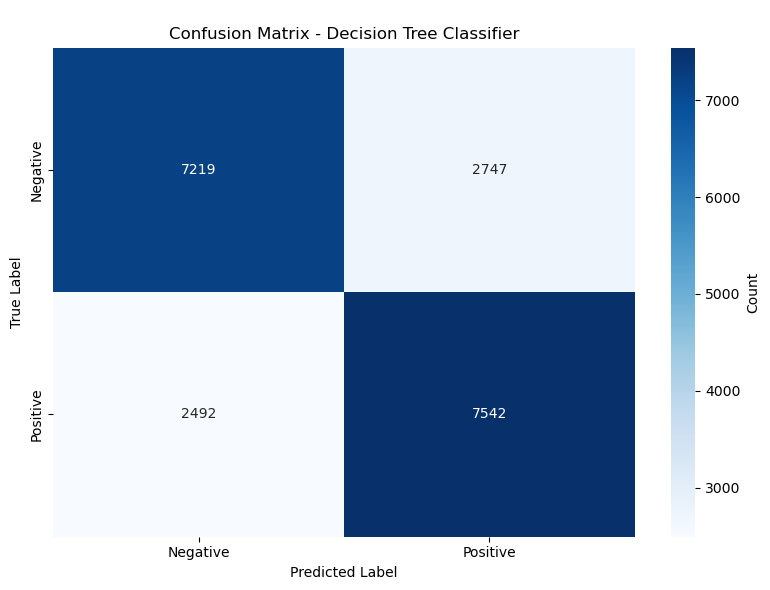

Confusion Matrix:
[[7219 2747]
 [2492 7542]]

True Negatives: 7219
False Positives: 2747
False Negatives: 2492
True Positives: 7542


In [9]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - Decision Tree Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Importance

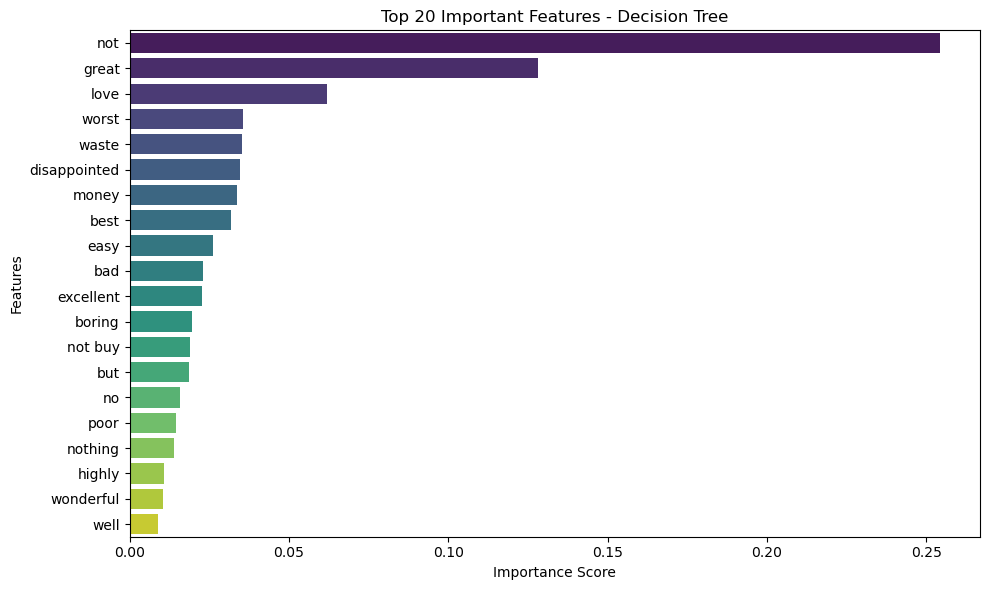


Top 20 Important Features:
     feature  importance
         not    0.254162
       great    0.128026
        love    0.062086
       worst    0.035594
       waste    0.035334
disappointed    0.034786
       money    0.033785
        best    0.031906
        easy    0.026241
         bad    0.023210
   excellent    0.022843
      boring    0.019757
     not buy    0.018925
         but    0.018686
          no    0.015684
        poor    0.014613
     nothing    0.013826
      highly    0.010667
   wonderful    0.010492
        well    0.009084


In [10]:
# Get feature importance
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance = dt_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Important Features - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('decision_tree_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Model Summary

In [11]:
print("DECISION TREE MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Max Depth: {dt_classifier.max_depth}")
print(f"  - Min Samples Split: {dt_classifier.min_samples_split}")
print(f"  - Min Samples Leaf: {dt_classifier.min_samples_leaf}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")

DECISION TREE MODEL SUMMARY

Model Parameters:
  - Max Depth: 15
  - Min Samples Split: 10
  - Min Samples Leaf: 5

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.7380
  - Precision: 0.7434
  - Recall:    0.7244
  - F1-Score:  0.7338
  - Training Time: 32.7700 seconds


## Saving the Model and Pipeline

In [12]:
save(model_base='data/models', model=dt_classifier, model_name='09_decision_tree_classifier.joblib')

Saved model 09_decision_tree_classifier.joblib to data/models/09_decision_tree_classifier.joblib


{'model': PosixPath('data/models/09_decision_tree_classifier.joblib')}